In [67]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [68]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [69]:
data = pd.read_csv(config['data']['raw']['file8'], quotechar='"', sep = "\t")

In [70]:
data.head(), data.shape, data.ID.nunique()

(     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
 0  5524        1957  Graduation         Single  58138.0        0         0   
 1  2174        1954  Graduation         Single  46344.0        1         1   
 2  4141        1965  Graduation       Together  71613.0        0         0   
 3  6182        1984  Graduation       Together  26646.0        1         0   
 4  5324        1981         PhD        Married  58293.0        1         0   
 
   Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
 0  04-09-2012       58       635  ...                  7             0   
 1  08-03-2014       38        11  ...                  5             0   
 2  21-08-2013       26       426  ...                  4             0   
 3  10-02-2014       26        11  ...                  6             0   
 4  19-01-2014       94       173  ...                  5             0   
 
    AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \


In [71]:
data.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [72]:
data = data.dropna(subset=['Income'])

In [73]:
data = data.drop(columns=['ID'])

In [74]:
data['age']= 2014-data.Year_Birth

In [75]:
data.Education.value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [76]:
data['Education']=data['Education'].replace({'Basic':'Undergraduate','2n Cycle':'Undergraduate','Graduation':'Postgraduate','Master':'Postgraduate','PhD':'PhD'})

In [77]:
data.Marital_Status.value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [78]:
data['Marital_Status']=data['Marital_Status'].replace({'Divorced':'Separated','Alone':'Single','Married':'Partnered','Together':'Partnered','Absurd':'Single','Widow':'Separated','YOLO':'Single'})

<Axes: ylabel='Income'>

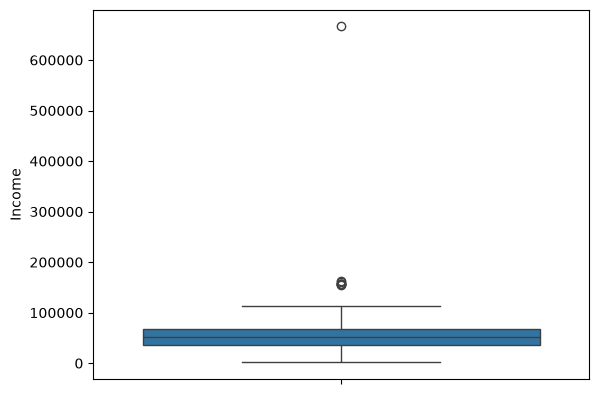

In [79]:
sns.boxplot(data=data,y='Income')

In [80]:
# extreme outlier
outlier_idx = np.where([data.Income==data.Income.max()])
data = data.drop(outlier_idx[1])

In [81]:
data['Num_Children'] = data.Kidhome + data.Teenhome
data = data.drop(columns=['Kidhome','Teenhome'])

In [82]:
data['Has_child']= data.Num_Children> 0

In [83]:
data.Has_child.value_counts()

Has_child
True     1582
False     633
Name: count, dtype: int64

In [84]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True,format = '%d-%m-%Y')
baseline_date = pd.to_datetime('2014-07-01')
data['Customer_Tenure_in_Days'] = (baseline_date - data['Dt_Customer']).dt.days
data = data.drop(columns=['Dt_Customer'])

In [85]:
data=data.rename(columns={'MntWines': "Wines",'MntFruits':'Fruits','MntMeatProducts':'Meat','MntFishProducts':'Fish','MntSweetProducts':'Sweets','MntGoldProds':'Gold'})

In [86]:
data['total_spend']=data['Wines']+data['Fruits']+data['Meat']+data['Fish']+data['Sweets']+data['Gold']

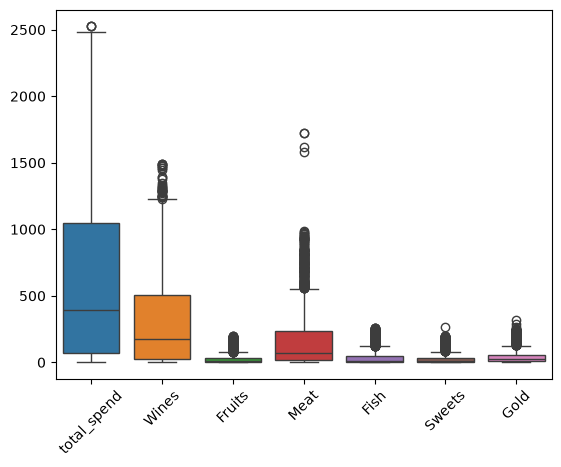

In [87]:
cols = ['total_spend', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

sns.boxplot(data=data[cols])
plt.xticks(rotation=45)
plt.show()

In [88]:
data=data.rename(columns={'NumDealsPurchases': "Deals",'NumWebPurchases':'Web','NumCatalogPurchases':'Catalogue','NumStorePurchases':'Store','NumWebVisitsMonth':'WebVisits'})

In [89]:
data.nunique()

Year_Birth                   59
Education                     3
Marital_Status                3
Income                     1973
Recency                     100
Wines                       776
Fruits                      158
Meat                        554
Fish                        182
Sweets                      176
Gold                        212
Deals                        15
Web                          15
Catalogue                    14
Store                        14
WebVisits                    16
AcceptedCmp3                  2
AcceptedCmp4                  2
AcceptedCmp5                  2
AcceptedCmp1                  2
AcceptedCmp2                  2
Complain                      2
Z_CostContact                 1
Z_Revenue                     1
Response                      2
age                          59
Num_Children                  4
Has_child                     2
Customer_Tenure_in_Days     662
total_spend                1047
dtype: int64

In [90]:
data.Z_Revenue.unique(), data.Z_CostContact.unique()

(array([11]), array([3]))

In [91]:
data.AcceptedCmp1.unique()

array([0, 1])

In [96]:
data['AcceptedCmp1'].sum(), data['AcceptedCmp2'].sum(), data['AcceptedCmp3'].sum(), data['AcceptedCmp4'].sum(), data['AcceptedCmp5'].sum(),data['Response'].sum()

(np.int64(142),
 np.int64(30),
 np.int64(163),
 np.int64(164),
 np.int64(162),
 np.int64(333))

In [93]:
data.shape

(2215, 30)

In [97]:
142/2215, 30/2215, 163/2215, 164/2215, 162/2215, 333/2215

(0.06410835214446953,
 0.013544018058690745,
 0.07358916478555305,
 0.07404063205417608,
 0.07313769751693003,
 0.15033860045146727)

In [59]:
data['Num_Camp_Success'] = data[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

In [60]:
data= data.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'])

In [57]:
data = data.drop(columns=['Z_Revenue','Z_CostContact'])

In [65]:
data.dtypes

year_birth                   int64
education                      str
marital_status                 str
income                     float64
recency                      int64
wines                        int64
fruits                       int64
meat                         int64
fish                         int64
sweets                       int64
gold                         int64
deals                        int64
web                          int64
catalogue                    int64
store                        int64
webvisits                    int64
complain                     int64
response                     int64
age                          int64
num_children                 int64
has_child                     bool
customer_tenure_in_days      int64
total_spend                  int64
num_camp_success             int64
dtype: object

In [64]:
data.columns = data.columns.map(lambda x: x.lower())

In [66]:
data.to_csv("../data/clean/marketing_campaign.csv", index=False, encoding= "utf-8", sep = ";")